# 04 — High-detail class-conditional spatial VAE

This notebook trains a **spatial conditional VAE (CVAE)** on the normalized
`128 × 128` log-mel spectrograms created by `02_preprocess_logmel.ipynb`.
It supersedes the first fully-connected-bottleneck baseline while preserving
that baseline's artifacts in `outputs/conditional_vae` and
`checkpoints/conditional_vae`.

The revision targets the baseline's main failure mode: broad energy envelopes
were reconstructed, but narrow transients, pitch tracks, and harmonic edges
were blurred.  The new experiment therefore combines:

1. a spatial `8 × 8` Gaussian latent map instead of a flat vector (128);
2. residual encoder/decoder blocks with class-wise FiLM modulation at every scale;
3. resize-convolution upsampling instead of transposed convolutions;
4. energy-weighted L1, multi-scale, and time/frequency gradient losses;
5. deterministic validation reconstructions and explicit detail-preservation metrics.

The model is still a compact CVAE baseline rather than a claim of SOTA.  Random
samples use the standard normal prior and are saved both as normalized `.npy`
tensors and optional Griffin-Lim waveform demonstrations.


## 1. Environment and dependencies

Required packages: `numpy`, `pandas`, `matplotlib`, and `torch`.

On Windows, `NUM_WORKERS = 0` is the safest Jupyter default. Mixed precision is
enabled automatically only when CUDA is available.


In [1]:
from __future__ import annotations

import json
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio, display
from torch.utils.data import DataLoader, Dataset

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.12.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti


## 2. Configuration and experiment isolation

Input paths continue to follow notebook `02`.  This revision uses new output
directories ending in `_v2`, so rerunning it cannot overwrite the original
five-downsampling, MSE-only CVAE baseline.

The defaults are sized for an 8 GB GPU.  `SMOKE_TEST=True` remains available
for a quick end-to-end contract check, but its outputs are not final results.


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent


@dataclass
class Config:
    # Paths
    PROJECT_ROOT: str = str(PROJECT_ROOT)
    SPECTROGRAM_CACHE_DIR: str = "artifacts/spectrograms"
    MANIFEST_DIR: str = "artifacts/spectrograms/manifests"
    TRAIN_MANIFEST: str = "spectrogram_train.csv"
    VAL_MANIFEST: str = "spectrogram_validation.csv"
    TEST_MANIFEST: str = "spectrogram_test.csv"
    NORMALIZATION_STATS: str = "artifacts/spectrograms/manifests/normalization_stats.json"
    PREPROCESSING_CONFIG: str = "artifacts/spectrograms/manifests/preprocessing_config.json"
    CHECKPOINT_DIR: str = "checkpoints/conditional_vae_v2"
    OUTPUT_DIR: str = "outputs/conditional_vae_v2"
    BASELINE_OUTPUT_DIR: str = "outputs/conditional_vae"

    # Reproducibility and loading
    SEED: int = 42
    NUM_WORKERS: int = 0
    PIN_MEMORY: bool = True

    # Data contract from notebook 02
    INPUT_CHANNELS: int = 1
    IMAGE_SIZE: int = 128
    TARGET_SPECIES: Tuple[str, ...] = (
        "Northern Cardinal",
        "Song Sparrow",
        "American Robin",
    )
    SPEC_PATH_CANDIDATES: Tuple[str, ...] = (
        "relative_spec_path",
        "spec_path",
        "spectrogram_path",
        "logmel_path",
        "npy_path",
        "processed_path",
    )
    SPECIES_COLUMN_CANDIDATES: Tuple[str, ...] = (
        "name",
        "species",
        "species_name",
        "label_name",
    )
    GROUP_COLUMN_CANDIDATES: Tuple[str, ...] = (
        "id",
        "recording_id",
        "original_recording_id",
        "xc_id",
    )

    # Spatial residual CVAE
    LATENT_CHANNELS: int = 16
    LATENT_SIZE: int = 8
    CLASS_EMBED_DIM: int = 64
    BASE_CHANNELS: int = 32

    # Detail-aware objective
    EVENT_WEIGHT: float = 1.5
    MULTISCALE_WEIGHT: float = 0.25
    TIME_GRAD_WEIGHT: float = 0.50
    FREQ_GRAD_WEIGHT: float = 0.50
    BETA_KL: float = 1e-3
    KL_WARMUP_EPOCHS: int = 15

    # Optimization
    BATCH_SIZE: int = 32
    MAX_EPOCHS: int = 60
    LEARNING_RATE: float = 2e-4
    WEIGHT_DECAY: float = 1e-5
    GRAD_CLIP_NORM: float = 5.0
    EARLY_STOPPING_PATIENCE: int = 12
    MIN_DELTA: float = 1e-4
    AMP: bool = True

    # Execution controls
    RUN_TRAINING: bool = True
    RESUME_FROM_LAST: bool = False
    SMOKE_TEST: bool = False
    SMOKE_TEST_BATCHES: int = 3
    SMOKE_TEST_EPOCHS: int = 2
    SAMPLES_PER_SPECIES: int = 16
    # Disabled by default: phase was discarded during preprocessing and
    # librosa inversion is unusually slow in the current Python 3.14 stack.
    SAVE_AUDIO_DEMOS: bool = False
    AUDIO_DEMOS_PER_SPECIES: int = 2
    GRIFFINLIM_ITERS: int = 32
    PRIOR_TEMPERATURE: float = 0.70


cfg = Config()
PROJECT_ROOT = Path(cfg.PROJECT_ROOT).resolve()
MANIFEST_DIR = PROJECT_ROOT / cfg.MANIFEST_DIR
CHECKPOINT_DIR = PROJECT_ROOT / cfg.CHECKPOINT_DIR
OUTPUT_DIR = PROJECT_ROOT / cfg.OUTPUT_DIR
BASELINE_OUTPUT_DIR = PROJECT_ROOT / cfg.BASELINE_OUTPUT_DIR

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(cfg.AMP and DEVICE.type == "cuda")

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Mixed precision:", AMP_ENABLED)
print("Smoke test:", cfg.SMOKE_TEST)
print("Output isolation:", OUTPUT_DIR)


Project root: C:\Users\sheng\Documents\1508_project\bird_song_gen
Device: cuda
Mixed precision: True
Smoke test: False
Output isolation: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2


In [3]:
PREPROCESSING_CONFIG_PATH = PROJECT_ROOT / cfg.PREPROCESSING_CONFIG
if not PREPROCESSING_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Missing preprocessing contract: {PREPROCESSING_CONFIG_PATH}\n"
        "Run notebook 02 first, or update PREPROCESSING_CONFIG in Config."
    )

with PREPROCESSING_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    preprocessing_config = json.load(handle)

preprocessed_shape = preprocessing_config.get("output", {}).get("shape")
preprocessed_species = preprocessing_config.get("target_species")
expected_shape = [cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE]

if preprocessed_shape != expected_shape:
    raise ValueError(
        f"Notebook 02 reports output shape {preprocessed_shape}; "
        f"this model expects {expected_shape}."
    )
if preprocessed_species != list(cfg.TARGET_SPECIES):
    raise ValueError(
        f"Notebook 02 reports species {preprocessed_species}; "
        f"this model expects {list(cfg.TARGET_SPECIES)}."
    )

print("Loaded preprocessing contract:", PREPROCESSING_CONFIG_PATH)
print("Preprocessed shape:", preprocessed_shape)
print("Preprocessed species:", preprocessed_species)


Loaded preprocessing contract: C:\Users\sheng\Documents\1508_project\bird_song_gen\artifacts\spectrograms\manifests\preprocessing_config.json
Preprocessed shape: [1, 128, 128]
Preprocessed species: ['Northern Cardinal', 'Song Sparrow', 'American Robin']


## 3. Reproducibility helpers

Deterministic settings improve repeatability, although exact GPU results can
still vary slightly across PyTorch/CUDA versions.


In [4]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(cfg.SEED)
generator = torch.Generator().manual_seed(cfg.SEED)


## 4. Load manifests and establish the label mapping

The split created in `01_dataset_audit.ipynb` must remain fixed. This section
also checks that an original recording ID does not occur in more than one split.

The notebook derives a deterministic label mapping from the selected species,
so it works even if the manifest does not already contain `label_id`.


In [5]:
def first_existing_column(df: pd.DataFrame, candidates: Tuple[str, ...], purpose: str) -> str:
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(
        f"Could not find a {purpose} column. Tried {list(candidates)}. "
        f"Available columns: {df.columns.tolist()}"
    )


def load_manifest(filename: str, split: str) -> pd.DataFrame:
    path = MANIFEST_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {split} manifest: {path}\n"
            "Run notebook 02 first, or update the path in Config."
        )
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"{split} manifest is empty: {path}")
    df = df.copy()
    df["split"] = split
    return df


train_df = load_manifest(cfg.TRAIN_MANIFEST, "train")
val_df = load_manifest(cfg.VAL_MANIFEST, "validation")
test_df = load_manifest(cfg.TEST_MANIFEST, "test")

SPECIES_COL = first_existing_column(
    train_df, cfg.SPECIES_COLUMN_CANDIDATES, "species"
)
SPEC_PATH_COL = first_existing_column(
    train_df, cfg.SPEC_PATH_CANDIDATES, "spectrogram path"
)

for split_name, frame in [("validation", val_df), ("test", test_df)]:
    if SPECIES_COL not in frame.columns or SPEC_PATH_COL not in frame.columns:
        raise KeyError(
            f"{split_name} manifest must contain {SPECIES_COL!r} and {SPEC_PATH_COL!r}."
        )

target_species = list(cfg.TARGET_SPECIES)
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    unexpected = sorted(set(frame[SPECIES_COL].dropna().unique()) - set(target_species))
    missing = sorted(set(target_species) - set(frame[SPECIES_COL].dropna().unique()))
    if unexpected:
        print(f"Warning: {split_name} has non-target species that will be removed: {unexpected}")
    if missing:
        raise ValueError(f"{split_name} is missing target species: {missing}")

train_df = train_df[train_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)
val_df = val_df[val_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)
test_df = test_df[test_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)

label_to_id = {species: idx for idx, species in enumerate(target_species)}
id_to_label = {idx: species for species, idx in label_to_id.items()}

for frame in (train_df, val_df, test_df):
    frame["label_id"] = frame[SPECIES_COL].map(label_to_id).astype(int)

summary = pd.concat(
    [
        train_df.groupby(SPECIES_COL).size().rename("train"),
        val_df.groupby(SPECIES_COL).size().rename("validation"),
        test_df.groupby(SPECIES_COL).size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int).reindex(target_species)

display(summary)
print("Label mapping:", label_to_id)
print("Total clips:", int(summary.to_numpy().sum()))


,train,validation,test
name,,,
Northern Cardinal,740,172,162
Song Sparrow,890,184,182
American Robin,709,163,145


Label mapping: {'Northern Cardinal': 0, 'Song Sparrow': 1, 'American Robin': 2}
Total clips: 3347


In [6]:
def find_common_group_column(frames: List[pd.DataFrame]) -> Optional[str]:
    for column in cfg.GROUP_COLUMN_CANDIDATES:
        if all(column in frame.columns for frame in frames):
            return column
    return None


GROUP_COL = find_common_group_column([train_df, val_df, test_df])
if GROUP_COL is None:
    print(
        "Warning: no original-recording ID column was found, so group leakage "
        "cannot be checked here. The split should already have been checked in notebook 01."
    )
else:
    train_groups = set(train_df[GROUP_COL].astype(str))
    val_groups = set(val_df[GROUP_COL].astype(str))
    test_groups = set(test_df[GROUP_COL].astype(str))
    overlaps = {
        "train_validation": train_groups & val_groups,
        "train_test": train_groups & test_groups,
        "validation_test": val_groups & test_groups,
    }
    assert all(len(values) == 0 for values in overlaps.values()), (
        "Original recording IDs cross split boundaries: "
        + str({key: list(value)[:5] for key, value in overlaps.items() if value})
    )
    print(f"No group leakage detected using column {GROUP_COL!r}.")


No group leakage detected using column 'id'.


## 5. Resolve and validate spectrogram paths

Paths in a CSV may be absolute or relative. Relative paths are tested against
the project root, the processed directory, and the manifest directory. This
cell validates every file before training begins.


In [7]:
def resolve_spec_path(path_value: str) -> Path:
    raw = Path(str(path_value))
    candidates = [raw] if raw.is_absolute() else [
        PROJECT_ROOT / raw,
        PROJECT_ROOT / cfg.SPECTROGRAM_CACHE_DIR / raw,
        MANIFEST_DIR / raw,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return candidates[0].resolve()


for frame in (train_df, val_df, test_df):
    frame["resolved_spec_path"] = frame[SPEC_PATH_COL].map(resolve_spec_path)

missing_paths = []
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = frame.loc[~frame["resolved_spec_path"].map(Path.exists), "resolved_spec_path"]
    missing_paths.extend([(split_name, str(path)) for path in missing.head(10)])
    print(f"{split_name:10s}: {len(frame):5d} rows, {len(missing):3d} missing tensors")

if missing_paths:
    raise FileNotFoundError(
        "Some preprocessed tensors are missing. First examples:\n"
        + "\n".join(f"  {split}: {path}" for split, path in missing_paths)
    )

# Inspect a few files before constructing data loaders.
for path in train_df["resolved_spec_path"].head(5):
    array = np.load(path, mmap_mode="r")
    assert array.shape == (cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), (
        f"Unexpected shape {array.shape} in {path}"
    )
    assert array.dtype == np.float32, f"Expected float32, got {array.dtype} in {path}"
    assert np.isfinite(array).all(), f"Non-finite values found in {path}"

print("Initial tensor checks passed.")


train     :  2339 rows,   0 missing tensors
validation:   519 rows,   0 missing tensors
test      :   489 rows,   0 missing tensors
Initial tensor checks passed.


## 6. Dataset and data loaders

Each item is returned as `(spectrogram, label_id, path)`. The path is retained
for traceability and later qualitative checks.


In [8]:
class BirdSpectrogramDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame):
        self.manifest = manifest.reset_index(drop=True).copy()

    def __len__(self) -> int:
        return len(self.manifest)

    def __getitem__(self, index: int):
        row = self.manifest.iloc[index]
        path = Path(row["resolved_spec_path"])
        array = np.load(path).astype(np.float32, copy=False)
        expected = (cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
        if array.shape != expected:
            raise ValueError(f"Expected {expected}, got {array.shape} in {path}")
        if not np.isfinite(array).all():
            raise ValueError(f"Non-finite values in {path}")
        x = torch.from_numpy(np.array(array, copy=True))
        y = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return x, y, str(path)


train_dataset = BirdSpectrogramDataset(train_df)
val_dataset = BirdSpectrogramDataset(val_df)
test_dataset = BirdSpectrogramDataset(test_df)

loader_kwargs = dict(
    batch_size=cfg.BATCH_SIZE,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=bool(cfg.PIN_MEMORY and DEVICE.type == "cuda"),
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=generator,
    drop_last=False,
    **loader_kwargs,
)
val_loader = DataLoader(val_dataset, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, drop_last=False, **loader_kwargs)

x_batch, y_batch, path_batch = next(iter(train_loader))
print("Batch spectrograms:", tuple(x_batch.shape), x_batch.dtype)
print("Batch labels:", tuple(y_batch.shape), y_batch.dtype)
print("Value range:", float(x_batch.min()), "to", float(x_batch.max()))
print("Mean / std:", float(x_batch.mean()), float(x_batch.std()))
print("First file:", path_batch[0])


Batch spectrograms: (32, 1, 128, 128) torch.float32
Batch labels: (32,) torch.int64
Value range: -1.9107701778411865 to 3.4603352546691895
Mean / std: 0.15140613913536072 1.0473195314407349
First file: C:\Users\sheng\Documents\1508_project\bird_song_gen\artifacts\spectrograms\train\northern_cardinal\302932-13.npy


## 7. Batch sanity check

The tensors are normalized model inputs. For visualization, the notebook tries
to load the training-set normalization mean and standard deviation and converts
them back to the log-mel dB scale. If the statistics file is unavailable, it
plots normalized values and labels them accordingly.


Training normalization mean/std: -51.5400096102764 14.894513218933453


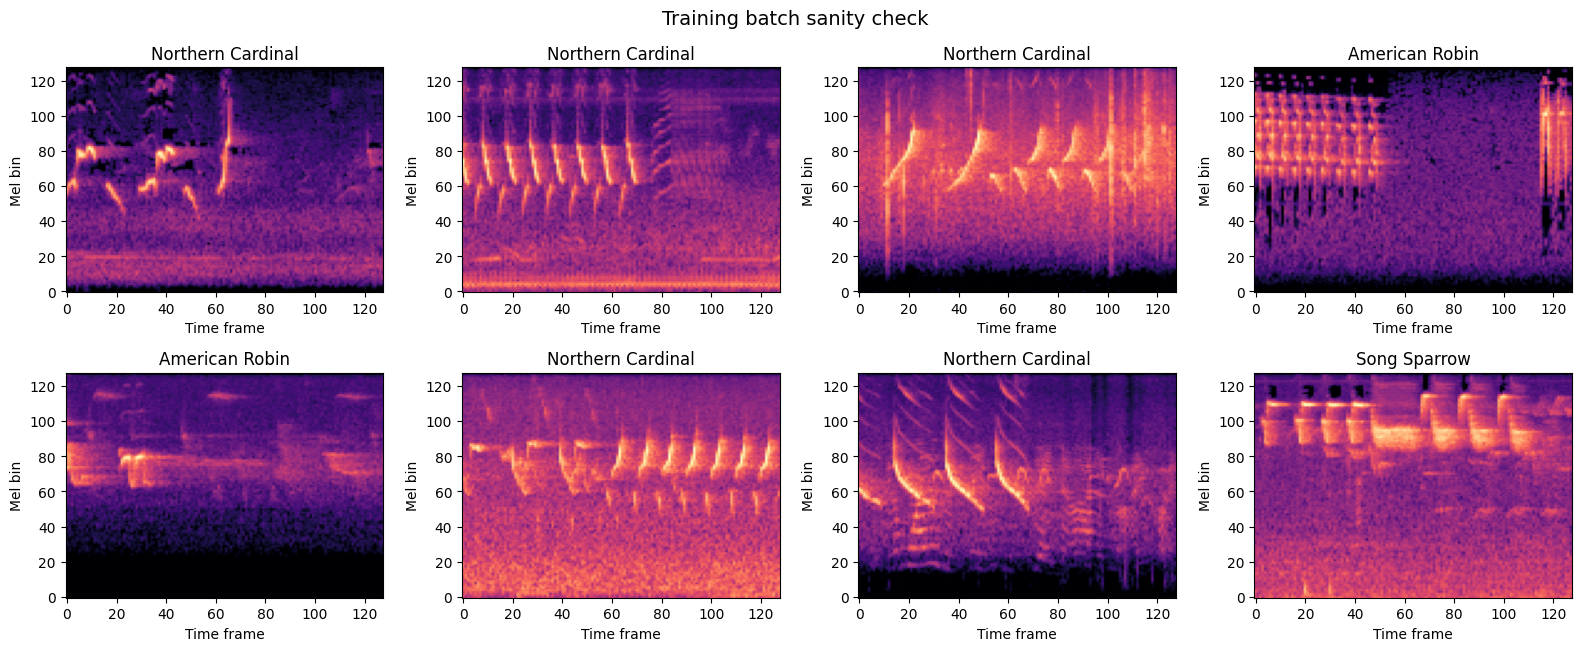

In [9]:
def load_normalization_stats() -> Tuple[Optional[float], Optional[float]]:
    path = PROJECT_ROOT / cfg.NORMALIZATION_STATS
    if not path.exists():
        print("Normalization statistics not found; plots will use normalized units:", path)
        return None, None
    with path.open("r", encoding="utf-8") as handle:
        stats = json.load(handle)

    mean_keys = ("mean_db", "mean", "train_mean", "global_mean", "mu_train")
    std_keys = ("std_db", "std", "train_std", "global_std", "sigma_train")
    mean = next((float(stats[key]) for key in mean_keys if key in stats), None)
    std = next((float(stats[key]) for key in std_keys if key in stats), None)
    if mean is None or std is None:
        print("Could not identify mean/std keys; plots will use normalized units.")
        return None, None
    return mean, std


TRAIN_MEAN, TRAIN_STD = load_normalization_stats()
print("Training normalization mean/std:", TRAIN_MEAN, TRAIN_STD)


def to_display_scale(x: torch.Tensor) -> np.ndarray:
    array = x.detach().cpu().float().numpy()
    if TRAIN_MEAN is not None and TRAIN_STD is not None:
        array = array * TRAIN_STD + TRAIN_MEAN
    return array


def show_spectrogram_grid(
    tensors: torch.Tensor,
    labels: torch.Tensor,
    title: str,
    max_items: int = 8,
) -> None:
    count = min(max_items, len(tensors))
    cols = min(4, count)
    rows = math.ceil(count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.3 * rows), squeeze=False)
    for index, axis in enumerate(axes.flat):
        axis.axis("off")
        if index >= count:
            continue
        image = to_display_scale(tensors[index, 0])
        axis.imshow(image, origin="lower", aspect="auto", cmap="magma")
        axis.set_title(id_to_label[int(labels[index])])
        axis.set_xlabel("Time frame")
        axis.set_ylabel("Mel bin")
        axis.axis("on")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


show_spectrogram_grid(x_batch, y_batch, "Training batch sanity check")


## 8. High-detail spatial conditional VAE

The baseline compressed the whole spectrogram into one 128-value vector after
reducing `128 × 128` to `4 × 4`.  That bottleneck discarded where narrow calls
and harmonics occurred.  This revision keeps a `16 × 8 × 8` stochastic latent
map, uses residual blocks, and injects the species condition by FiLM at every
encoder and decoder resolution.

Bilinear resize followed by a `3 × 3` convolution avoids the periodic artifacts
that transposed convolutions can introduce.  Validation and visualization decode
the posterior mean; training still uses reparameterized samples.

Design sources:

- NVAE and Very Deep VAE: residual, spatial, hierarchical VAE design for stronger
  high-resolution generation.
- Ladder VAE: deterministic KL warm-up for stable use of stochastic latents.
- RAVE: reconstruction fidelity and latent regularity are separate objectives;
  audio quality needs more than pixel loss alone.


In [10]:
def group_count(channels: int, maximum: int = 8) -> int:
    for groups in range(min(maximum, channels), 0, -1):
        if channels % groups == 0:
            return groups
    return 1


class ConditionalResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, condition_dim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(group_count(in_channels), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(group_count(out_channels), out_channels)
        self.film = nn.Linear(condition_dim, out_channels * 2)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )
        nn.init.zeros_(self.film.weight)
        nn.init.zeros_(self.film.bias)
        nn.init.zeros_(self.conv2.weight)
        nn.init.zeros_(self.conv2.bias)

    def forward(self, x: torch.Tensor, condition: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        h = self.conv1(F.silu(self.norm1(x)))
        h = self.norm2(h)
        scale, shift = self.film(condition).chunk(2, dim=1)
        h = h * (1.0 + 0.1 * torch.tanh(scale[:, :, None, None]))
        h = h + shift[:, :, None, None]
        h = self.conv2(F.silu(h))
        return residual + h


class Downsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=2, padding=1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=False)
        return self.conv(x)


class ConditionalVAE(nn.Module):
    def __init__(
        self,
        num_classes: int,
        image_size: int = 128,
        input_channels: int = 1,
        latent_channels: int = 16,
        latent_size: int = 8,
        class_embed_dim: int = 64,
        base_channels: int = 32,
    ):
        super().__init__()
        if image_size != 128 or latent_size != 8:
            raise ValueError("This architecture expects 128×128 inputs and an 8×8 latent map.")

        self.num_classes = num_classes
        self.image_size = image_size
        self.input_channels = input_channels
        self.latent_channels = latent_channels
        self.latent_size = latent_size
        self.latent_dim = latent_channels * latent_size * latent_size
        self.class_embed_dim = class_embed_dim
        self.base_channels = base_channels

        self.class_embedding = nn.Embedding(num_classes, class_embed_dim)
        b = base_channels

        self.encoder_stem = nn.Conv2d(input_channels, b, kernel_size=3, padding=1)
        self.encoder_blocks = nn.ModuleList(
            [
                ConditionalResBlock(b, b, class_embed_dim),
                ConditionalResBlock(b * 2, b * 2, class_embed_dim),
                ConditionalResBlock(b * 4, b * 4, class_embed_dim),
                ConditionalResBlock(b * 6, b * 6, class_embed_dim),
                ConditionalResBlock(b * 8, b * 8, class_embed_dim),
            ]
        )
        self.downsamples = nn.ModuleList(
            [
                Downsample(b, b * 2),
                Downsample(b * 2, b * 4),
                Downsample(b * 4, b * 6),
                Downsample(b * 6, b * 8),
            ]
        )
        self.encoder_tail = ConditionalResBlock(b * 8, b * 8, class_embed_dim)
        self.mu_head = nn.Conv2d(b * 8, latent_channels, kernel_size=3, padding=1)
        self.logvar_head = nn.Conv2d(b * 8, latent_channels, kernel_size=3, padding=1)

        self.decoder_stem = nn.Conv2d(latent_channels, b * 8, kernel_size=3, padding=1)
        self.decoder_tail = ConditionalResBlock(b * 8, b * 8, class_embed_dim)
        self.upsamples = nn.ModuleList(
            [
                Upsample(b * 8, b * 6),
                Upsample(b * 6, b * 4),
                Upsample(b * 4, b * 2),
                Upsample(b * 2, b),
            ]
        )
        self.decoder_blocks = nn.ModuleList(
            [
                ConditionalResBlock(b * 6, b * 6, class_embed_dim),
                ConditionalResBlock(b * 4, b * 4, class_embed_dim),
                ConditionalResBlock(b * 2, b * 2, class_embed_dim),
                ConditionalResBlock(b, b, class_embed_dim),
            ]
        )
        self.output_norm = nn.GroupNorm(group_count(b), b)
        self.output_conv = nn.Conv2d(b, input_channels, kernel_size=3, padding=1)

    def encode(self, x: torch.Tensor, labels: torch.Tensor):
        condition = self.class_embedding(labels)
        h = self.encoder_stem(x)
        for index, block in enumerate(self.encoder_blocks):
            h = block(h, condition)
            if index < len(self.downsamples):
                h = self.downsamples[index](h)
        h = self.encoder_tail(h, condition)
        return self.mu_head(h), self.logvar_head(h)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        condition = self.class_embedding(labels)
        h = self.decoder_tail(self.decoder_stem(z), condition)
        for upsample, block in zip(self.upsamples, self.decoder_blocks):
            h = block(upsample(h), condition)
        return self.output_conv(F.silu(self.output_norm(h)))

    def forward(
        self,
        x: torch.Tensor,
        labels: torch.Tensor,
        sample_latent: bool = True,
    ):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar) if sample_latent else mu
        return self.decode(z, labels), mu, logvar

    @torch.no_grad()
    def sample(
        self,
        labels: torch.Tensor,
        generator: Optional[torch.Generator] = None,
        temperature: float = 1.0,
    ) -> torch.Tensor:
        z = torch.randn(
            len(labels),
            self.latent_channels,
            self.latent_size,
            self.latent_size,
            device=labels.device,
            generator=generator,
        ) * temperature
        return self.decode(z, labels)


model = ConditionalVAE(
    num_classes=len(label_to_id),
    image_size=cfg.IMAGE_SIZE,
    input_channels=cfg.INPUT_CHANNELS,
    latent_channels=cfg.LATENT_CHANNELS,
    latent_size=cfg.LATENT_SIZE,
    class_embed_dim=cfg.CLASS_EMBED_DIM,
    base_channels=cfg.BASE_CHANNELS,
).to(DEVICE)

with torch.no_grad():
    sample_x = x_batch[:2].to(DEVICE)
    sample_y = y_batch[:2].to(DEVICE)
    sample_recon, sample_mu, sample_logvar = model(
        sample_x, sample_y, sample_latent=False
    )

expected_latent = (2, cfg.LATENT_CHANNELS, cfg.LATENT_SIZE, cfg.LATENT_SIZE)
assert sample_recon.shape == sample_x.shape
assert sample_mu.shape == expected_latent
assert sample_logvar.shape == expected_latent
print("Forward-pass shape check passed:", tuple(sample_recon.shape))
print("Spatial latent shape:", tuple(sample_mu.shape[1:]))


Forward-pass shape check passed: (2, 1, 128, 128)
Spatial latent shape: (16, 8, 8)


## 9. Model size and a quick memory check

The parameter count is reported to address the compute-resource concern. Actual peak memory is measured during training when CUDA is
available.


In [11]:
def count_parameters(module: nn.Module) -> Dict[str, int]:
    total = sum(parameter.numel() for parameter in module.parameters())
    trainable = sum(
        parameter.numel() for parameter in module.parameters() if parameter.requires_grad
    )
    return {"total": total, "trainable": trainable}


parameter_counts = count_parameters(model)
parameter_memory_mb = parameter_counts["total"] * 4 / (1024 ** 2)

print(f"Total parameters:     {parameter_counts['total']:,}")
print(f"Trainable parameters: {parameter_counts['trainable']:,}")
print(f"FP32 parameter memory only: {parameter_memory_mb:.1f} MB")

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


Total parameters:     7,482,017
Trainable parameters: 7,482,017
FP32 parameter memory only: 28.5 MB


## 10. Detail-aware VAE objective

Pure MSE rewards conditional averages and blurred the baseline's thin frequency
tracks.  The revised distortion term combines:

- energy-weighted L1, so active bird-call bins matter more than background;
- pooled L1 at `2×` and `4×` scales for the global time-frequency envelope;
- first-difference losses along time (transients) and mel frequency (harmonic edges).

This is deliberately lighter and more stable than adversarial fine-tuning on this
dataset.  The principle follows multi-resolution spectral objectives used in
Parallel WaveGAN and gradient-difference objectives introduced to address the
characteristic blur of pixel MSE.  The KL term is still warmed up linearly.


In [12]:
def first_difference(x: torch.Tensor, dimension: int) -> torch.Tensor:
    if dimension == -1:
        return x[..., 1:] - x[..., :-1]
    if dimension == -2:
        return x[..., 1:, :] - x[..., :-1, :]
    raise ValueError("Only the time (-1) and frequency (-2) dimensions are supported.")


def detail_aware_reconstruction_loss(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
) -> Dict[str, torch.Tensor]:
    absolute_error = (reconstruction - target).abs()
    event_weights = 1.0 + cfg.EVENT_WEIGHT * torch.sigmoid(target)
    weighted_l1 = (absolute_error * event_weights).sum() / event_weights.sum()

    pooled_losses = []
    for scale in (2, 4):
        pooled_reconstruction = F.avg_pool2d(reconstruction, scale)
        pooled_target = F.avg_pool2d(target, scale)
        pooled_losses.append(F.l1_loss(pooled_reconstruction, pooled_target))
    multiscale_l1 = torch.stack(pooled_losses).mean()

    reconstruction_dt = first_difference(reconstruction, -1)
    target_dt = first_difference(target, -1)
    reconstruction_df = first_difference(reconstruction, -2)
    target_df = first_difference(target, -2)
    time_edge_weights = 1.0 + target_dt.abs().detach()
    freq_edge_weights = 1.0 + target_df.abs().detach()
    time_grad = ((reconstruction_dt - target_dt).abs() * time_edge_weights).mean()
    freq_grad = ((reconstruction_df - target_df).abs() * freq_edge_weights).mean()

    objective = (
        weighted_l1
        + cfg.MULTISCALE_WEIGHT * multiscale_l1
        + cfg.TIME_GRAD_WEIGHT * time_grad
        + cfg.FREQ_GRAD_WEIGHT * freq_grad
    )
    mse = F.mse_loss(reconstruction, target)
    mae = absolute_error.mean()
    return {
        "recon": objective,
        "mse": mse,
        "mae": mae,
        "multiscale": multiscale_l1,
        "time_grad": time_grad,
        "freq_grad": freq_grad,
    }


def vae_loss(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    parts = detail_aware_reconstruction_loss(reconstruction, target)
    kl_loss = -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())
    total_loss = parts["recon"] + beta * kl_loss
    parts = {"loss": total_loss, **parts, "kl": kl_loss}
    return total_loss, parts


def beta_for_epoch(epoch: int) -> float:
    if cfg.KL_WARMUP_EPOCHS <= 0:
        return cfg.BETA_KL
    fraction = min(1.0, epoch / cfg.KL_WARMUP_EPOCHS)
    return cfg.BETA_KL * fraction


test_loss, test_parts = vae_loss(
    sample_recon, sample_x, sample_mu, sample_logvar, beta=cfg.BETA_KL
)
print({key: float(value) for key, value in test_parts.items()})


{'loss': 1.358233094215393, 'recon': 1.3582322597503662, 'mse': 0.8292531967163086, 'mae': 0.7171337604522705, 'multiscale': 0.6854805946350098, 'time_grad': 0.5190420150756836, 'freq_grad': 0.32227426767349243, 'kl': 0.000777109176851809}


## 11. Training and validation utilities

Training uses sampled latents. Validation and test evaluation decode the
posterior mean to remove sampling noise from checkpoint selection. The logged
`recon` value is the composite detail-aware objective; `mse` is retained for a
direct comparison with the original baseline.


In [13]:
def make_grad_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context(enabled: bool):
    try:
        return torch.amp.autocast(device_type=DEVICE.type, enabled=enabled)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=enabled)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    beta: float,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler=None,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    is_training = optimizer is not None
    model.train(is_training)
    totals: Dict[str, float] = {}
    sample_count = 0

    for batch_index, (x, labels, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break

        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        batch_size = len(x)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with autocast_context(AMP_ENABLED):
                reconstruction, mu, logvar = model(
                    x, labels, sample_latent=is_training
                )
                loss, parts = vae_loss(reconstruction, x, mu, logvar, beta)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()

        for key, value in parts.items():
            totals[key] = totals.get(key, 0.0) + float(value.detach()) * batch_size
        sample_count += batch_size

    if sample_count == 0:
        raise RuntimeError("No samples were processed in this epoch.")
    return {key: value / sample_count for key, value in totals.items()}


def save_checkpoint(
    path: Path,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler,
    history: Dict[str, List[float]],
    best_val_loss: float,
) -> None:
    payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "best_val_loss": best_val_loss,
        "config": asdict(cfg),
        "label_to_id": label_to_id,
        "parameter_counts": parameter_counts,
    }
    torch.save(payload, path)


def load_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler=None,
):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    return checkpoint


## 12. Train the revised model

Checkpoints are selected by the complete detail-aware validation objective,
not MSE alone. The baseline checkpoint remains untouched in
`checkpoints/conditional_vae/conditional_vae_best.pt`.


In [14]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
)
scaler = make_grad_scaler(AMP_ENABLED)

tracked_metrics = [
    "loss", "recon", "mse", "mae", "multiscale", "time_grad", "freq_grad", "kl"
]
history = {"epoch": [], "beta": [], "epoch_seconds": []}
for split in ("train", "val"):
    for metric in tracked_metrics:
        history[f"{split}_{metric}"] = []

best_path = CHECKPOINT_DIR / "conditional_vae_v2_best.pt"
last_path = CHECKPOINT_DIR / "conditional_vae_v2_last.pt"
start_epoch = 1
best_val_loss = float("inf")
epochs_without_improvement = 0

if cfg.RESUME_FROM_LAST and last_path.exists():
    checkpoint = load_checkpoint(last_path, model, optimizer, scaler)
    start_epoch = int(checkpoint["epoch"]) + 1
    history = checkpoint.get("history", history)
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    print(f"Resuming from epoch {start_epoch} using {last_path}")

max_epochs = cfg.SMOKE_TEST_EPOCHS if cfg.SMOKE_TEST else cfg.MAX_EPOCHS
max_batches = cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None
training_start = time.perf_counter()

if cfg.RUN_TRAINING:
    for epoch in range(start_epoch, max_epochs + 1):
        epoch_start = time.perf_counter()
        beta = beta_for_epoch(epoch)
        train_metrics = run_epoch(
            model, train_loader, beta, optimizer, scaler, max_batches
        )
        val_metrics = run_epoch(
            model, val_loader, beta, None, None, max_batches
        )

        elapsed = time.perf_counter() - epoch_start
        history["epoch"].append(epoch)
        history["beta"].append(beta)
        history["epoch_seconds"].append(elapsed)
        for metric in tracked_metrics:
            history[f"train_{metric}"].append(train_metrics[metric])
            history[f"val_{metric}"].append(val_metrics[metric])

        improved = val_metrics["loss"] < best_val_loss - cfg.MIN_DELTA
        if improved:
            best_val_loss = val_metrics["loss"]
            epochs_without_improvement = 0
            save_checkpoint(
                best_path, epoch, model, optimizer, scaler, history, best_val_loss
            )
        else:
            epochs_without_improvement += 1

        save_checkpoint(
            last_path, epoch, model, optimizer, scaler, history, best_val_loss
        )
        print(
            f"Epoch {epoch:03d}/{max_epochs:03d} | beta={beta:.5f} | "
            f"train={train_metrics['loss']:.4f} "
            f"(mse={train_metrics['mse']:.4f}, dt={train_metrics['time_grad']:.4f}, "
            f"df={train_metrics['freq_grad']:.4f}, kl={train_metrics['kl']:.3f}) | "
            f"val={val_metrics['loss']:.4f} "
            f"(mse={val_metrics['mse']:.4f}, dt={val_metrics['time_grad']:.4f}, "
            f"df={val_metrics['freq_grad']:.4f}, kl={val_metrics['kl']:.3f}) | "
            f"{elapsed:.1f}s" + (" | saved best" if improved else "")
        )

        if epochs_without_improvement >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break

    total_training_seconds = time.perf_counter() - training_start
    print(f"Training section elapsed: {total_training_seconds / 60:.1f} minutes")
else:
    total_training_seconds = 0.0
    print("RUN_TRAINING is False; no optimization was performed.")

if best_path.exists():
    best_checkpoint = load_checkpoint(best_path, model)
    history = best_checkpoint.get("history", history)
    print("Loaded best checkpoint from epoch", best_checkpoint["epoch"])
else:
    print("No best checkpoint exists yet. Run training before final evaluation.")

if DEVICE.type == "cuda":
    peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
    print(f"Peak allocated CUDA memory: {peak_memory_gb:.2f} GB")
else:
    peak_memory_gb = None


RUN_TRAINING is False; no optimization was performed.
Loaded best checkpoint from epoch 60
Peak allocated CUDA memory: 0.12 GB


## 13. Training curves

Inspect reconstruction and KL terms separately. A KL value that collapses close
to zero may indicate that the decoder is ignoring the latent variable. If that
happens, reduce `BETA_KL`, lengthen warm-up, or reduce decoder capacity.


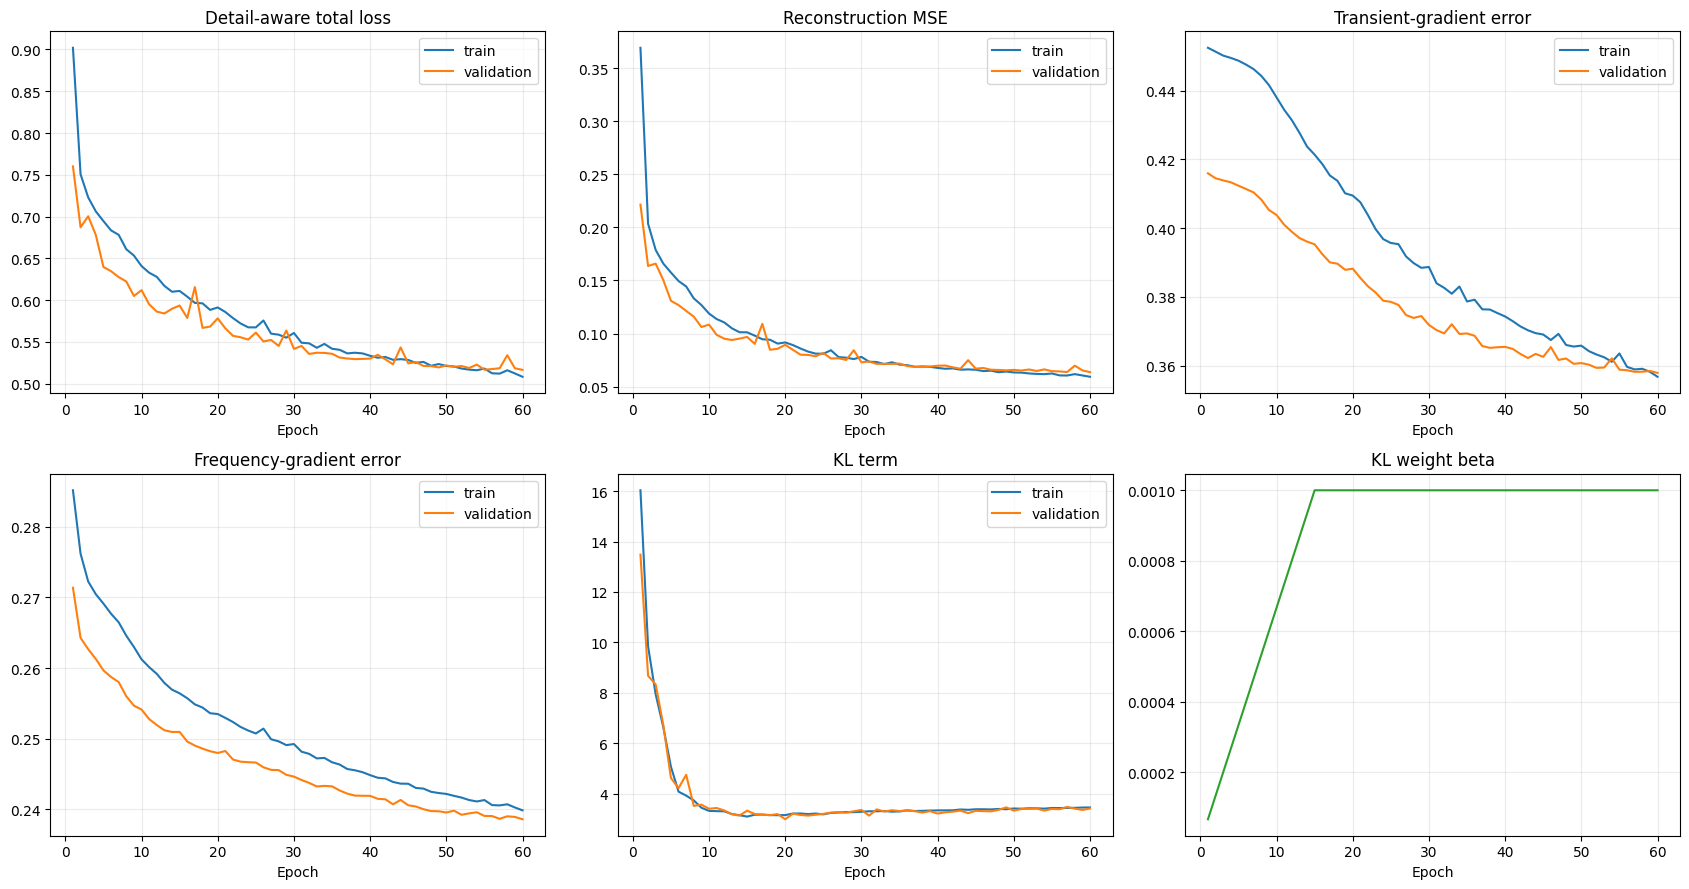

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\training_curves.png


In [15]:
def plot_training_history(history: Dict[str, List[float]]) -> None:
    if not history["epoch"]:
        print("No history to plot.")
        return

    epochs = history["epoch"]
    panels = [
        ("loss", "Detail-aware total loss"),
        ("mse", "Reconstruction MSE"),
        ("time_grad", "Transient-gradient error"),
        ("freq_grad", "Frequency-gradient error"),
        ("kl", "KL term"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    for axis, (metric, title) in zip(axes.flat, panels):
        axis.plot(epochs, history[f"train_{metric}"], label="train")
        axis.plot(epochs, history[f"val_{metric}"], label="validation")
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend()

    axes.flat[-1].plot(epochs, history["beta"], color="tab:green")
    axes.flat[-1].set_title("KL weight beta")
    axes.flat[-1].set_xlabel("Epoch")
    axes.flat[-1].grid(alpha=0.25)
    fig.tight_layout()
    figure_path = OUTPUT_DIR / "training_curves.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)


plot_training_history(history)


## 14. Held-out test reconstruction metrics

Reconstruction is meaningful for the VAE, but it is not the only measure of
generation quality. Notebook `06` will compare freely generated VAE and
diffusion samples using shared metrics.


In [16]:
@torch.no_grad()
def evaluate_detail_metrics(
    model: ConditionalVAE,
    loader: DataLoader,
    max_batches: Optional[int] = None,
) -> Dict[str, float]:
    model.eval()
    totals = {
        "spectral_convergence": 0.0,
        "time_gradient_ratio": 0.0,
        "frequency_gradient_ratio": 0.0,
        "time_gradient_cosine": 0.0,
        "frequency_gradient_cosine": 0.0,
    }
    sample_count = 0
    epsilon = 1e-8
    for batch_index, (x, labels, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        reconstruction, _, _ = model(x, labels, sample_latent=False)
        batch_size = len(x)

        target_dt = first_difference(x, -1).flatten(1)
        recon_dt = first_difference(reconstruction, -1).flatten(1)
        target_df = first_difference(x, -2).flatten(1)
        recon_df = first_difference(reconstruction, -2).flatten(1)
        spectral = (
            (reconstruction - x).flatten(1).norm(dim=1)
            / (x.flatten(1).norm(dim=1) + epsilon)
        )
        time_ratio = recon_dt.abs().mean(1) / (target_dt.abs().mean(1) + epsilon)
        freq_ratio = recon_df.abs().mean(1) / (target_df.abs().mean(1) + epsilon)
        time_cosine = F.cosine_similarity(recon_dt, target_dt, dim=1)
        freq_cosine = F.cosine_similarity(recon_df, target_df, dim=1)

        values = {
            "spectral_convergence": spectral,
            "time_gradient_ratio": time_ratio,
            "frequency_gradient_ratio": freq_ratio,
            "time_gradient_cosine": time_cosine,
            "frequency_gradient_cosine": freq_cosine,
        }
        for key, value in values.items():
            totals[key] += float(value.sum())
        sample_count += batch_size
    return {key: value / sample_count for key, value in totals.items()}


if best_path.exists():
    test_metrics = run_epoch(
        model,
        test_loader,
        beta=cfg.BETA_KL,
        optimizer=None,
        scaler=None,
        max_batches=cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None,
    )
    test_metrics.update(
        evaluate_detail_metrics(
            model,
            test_loader,
            max_batches=cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None,
        )
    )
    print("Held-out deterministic test metrics:")
    for key, value in test_metrics.items():
        print(f"  {key:26s}: {value:.6f}")
else:
    test_metrics = {}
    print("Train the model first to compute meaningful test metrics.")


Held-out deterministic test metrics:
  loss                      : 0.522229
  recon                     : 0.518803
  mse                       : 0.065388
  mae                       : 0.189413
  multiscale                : 0.096699
  time_grad                 : 0.359458
  freq_grad                 : 0.242697
  kl                        : 3.426105
  spectral_convergence      : 0.272697
  time_gradient_ratio       : 0.328652
  frequency_gradient_ratio  : 0.389184
  time_gradient_cosine      : 0.450290
  frequency_gradient_cosine : 0.486281


## 15. Reconstruction examples by species

The comparison below uses unseen test inputs and displays the encoder mean
$\mu$ rather than a random posterior sample, making the reconstruction panel
repeatable.


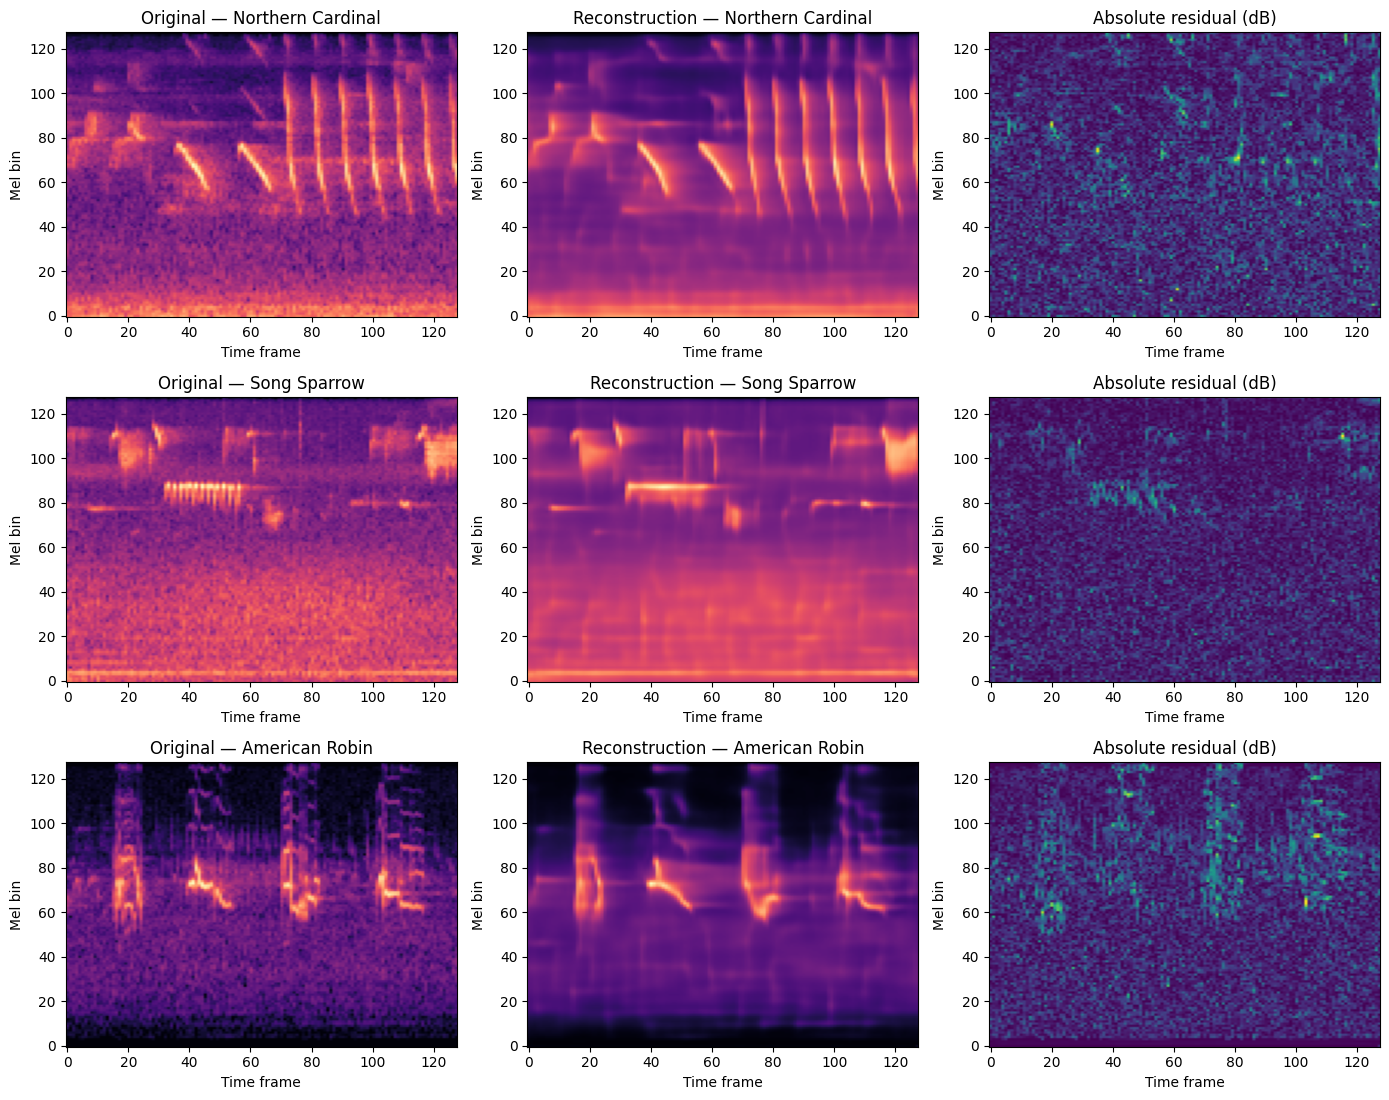

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\test_reconstructions.png


In [17]:
def collect_one_per_species(dataset: BirdSpectrogramDataset):
    found = {}
    for index in range(len(dataset)):
        x, label, path = dataset[index]
        label_id = int(label)
        if label_id not in found:
            found[label_id] = (x, label, path)
        if len(found) == len(label_to_id):
            break
    return [found[index] for index in range(len(label_to_id))]


@torch.no_grad()
def plot_reconstructions(model: ConditionalVAE) -> None:
    examples = collect_one_per_species(test_dataset)
    x = torch.stack([item[0] for item in examples]).to(DEVICE)
    labels = torch.stack([item[1] for item in examples]).to(DEVICE)
    model.eval()
    reconstructions, _, _ = model(x, labels, sample_latent=False)

    fig, axes = plt.subplots(len(examples), 3, figsize=(14, 3.7 * len(examples)))
    for row in range(len(examples)):
        original = to_display_scale(x[row, 0])
        reconstructed = to_display_scale(reconstructions[row, 0])
        residual = np.abs(original - reconstructed)
        common_min = min(float(original.min()), float(reconstructed.min()))
        common_max = max(float(original.max()), float(reconstructed.max()))
        species = id_to_label[int(labels[row])]

        axes[row, 0].imshow(original, origin="lower", aspect="auto", cmap="magma",
                            vmin=common_min, vmax=common_max)
        axes[row, 1].imshow(reconstructed, origin="lower", aspect="auto", cmap="magma",
                            vmin=common_min, vmax=common_max)
        axes[row, 2].imshow(residual, origin="lower", aspect="auto", cmap="viridis")
        axes[row, 0].set_title(f"Original — {species}")
        axes[row, 1].set_title(f"Reconstruction — {species}")
        axes[row, 2].set_title("Absolute residual (dB)")
        for axis in axes[row]:
            axis.set_xlabel("Time frame")
            axis.set_ylabel("Mel bin")

    fig.tight_layout()
    figure_path = OUTPUT_DIR / "test_reconstructions.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)


if best_path.exists():
    plot_reconstructions(model)
else:
    print("Train the model first.")


## 16. Conditional generation, detail checks, and waveform demonstrations

A weak-KL spatial model can leave a large gap between its aggregated posterior
and `N(0, I)`. Before generation, this notebook moment-matches one diagonal
Gaussian per species to the **training** posteriors. This empirical-Bayes prior
is a lightweight version of the learned/mixture-prior idea behind VampPrior and
prevents random decoding from an obviously out-of-distribution latent region.

Random samples are stored under one directory per species so the existing
classifier evaluation script can infer target labels from parent folders.
The notebook also compares generated time/frequency gradient energy with the
held-out real distribution; a ratio near `1` means the output has comparable
local detail energy, though it does not by itself prove realism.

Griffin-Lim waveforms are saved only as auditable demonstrations.  Because the
preprocessing contract discards phase, this inversion puts a ceiling on audible
fidelity; a neural vocoder is the appropriate later replacement.


Saved fitted class-conditional sampling prior: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\class_conditional_aggregated_prior.pt
Saved generated manifest: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\generated_manifest.csv


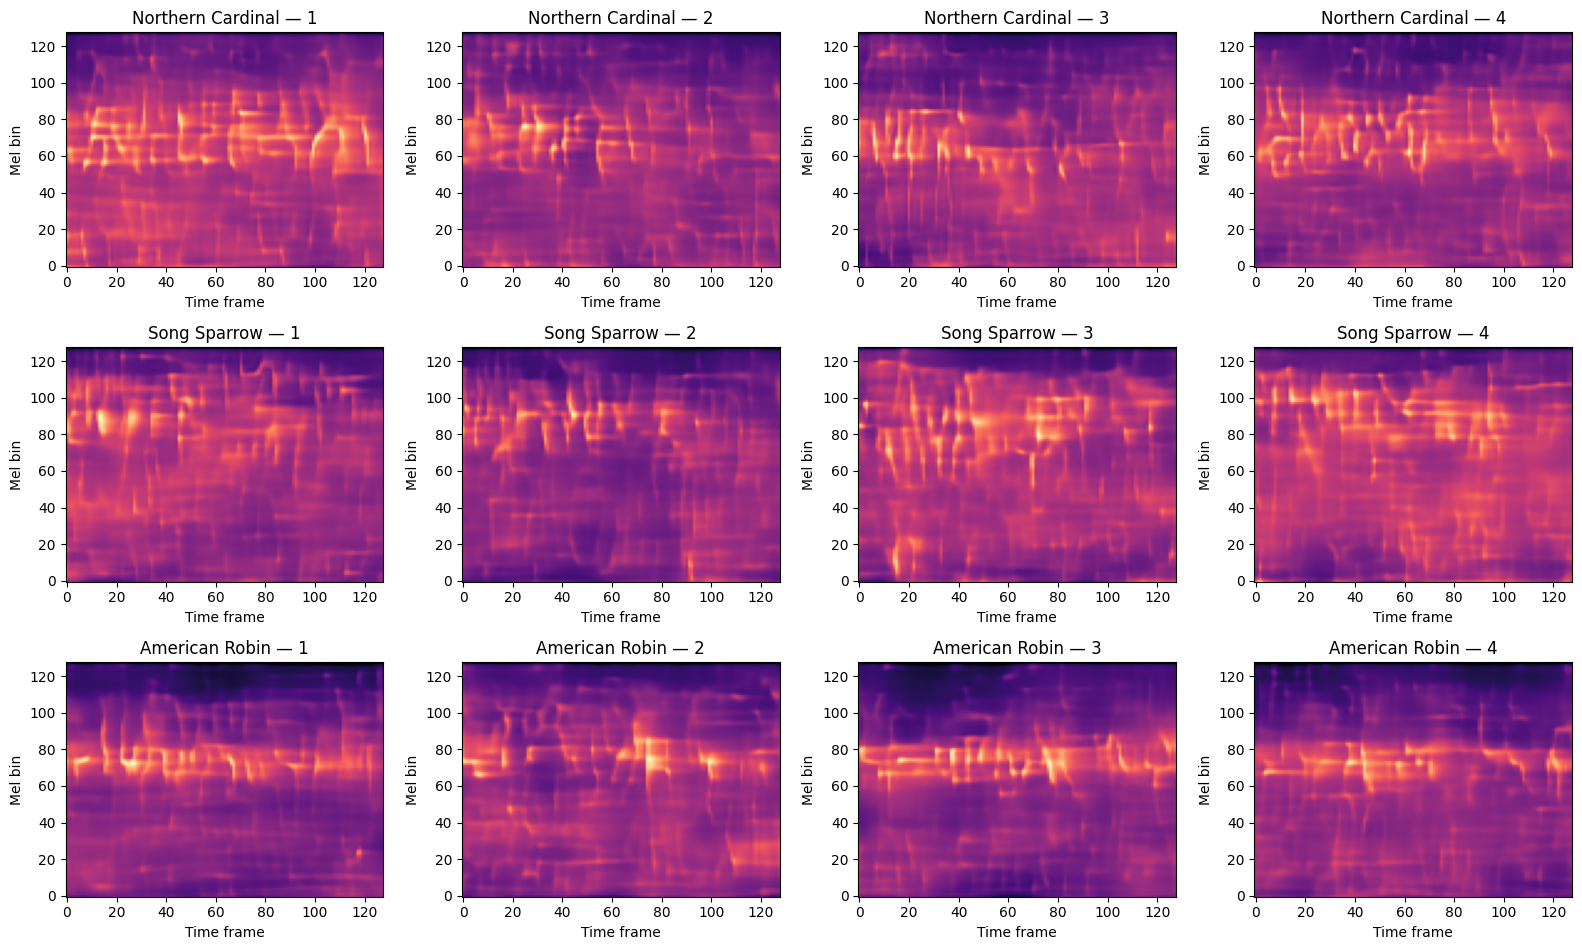

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\conditional_samples.png


,species,real_time_gradient_energy,real_frequency_gradient_energy,generated_time_gradient_energy,generated_frequency_gradient_energy,time_detail_ratio,frequency_detail_ratio
0,Northern Cardinal,0.286307,0.201249,0.105159,0.079900,0.367294,0.397023
1,Song Sparrow,0.272544,0.210466,0.094454,0.075778,0.346565,0.360048
2,American Robin,0.247091,0.195077,0.082374,0.075369,0.333373,0.386356


Saved generated-detail comparison: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\generated_detail_metrics.csv
Saved 0 Griffin-Lim audio demonstrations.


In [18]:
@torch.no_grad()
def fit_class_conditional_aggregated_prior(
    model: ConditionalVAE,
    loader: DataLoader,
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    latent_shape = (cfg.LATENT_CHANNELS, cfg.LATENT_SIZE, cfg.LATENT_SIZE)
    sums = torch.zeros(len(label_to_id), *latent_shape, device=DEVICE)
    second_moments = torch.zeros_like(sums)
    counts = torch.zeros(len(label_to_id), device=DEVICE)

    for x, labels, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mu, logvar = model.encode(x, labels)
        posterior_second_moment = mu.square() + logvar.exp()
        sums.index_add_(0, labels, mu)
        second_moments.index_add_(0, labels, posterior_second_moment)
        counts.index_add_(0, labels, torch.ones_like(labels, dtype=torch.float32))

    means = sums / counts[:, None, None, None]
    variances = second_moments / counts[:, None, None, None] - means.square()
    standard_deviations = variances.clamp_min(1e-4).sqrt().clamp_max(3.0)
    prior_path = OUTPUT_DIR / "class_conditional_aggregated_prior.pt"
    torch.save(
        {
            "mean": means.cpu(),
            "std": standard_deviations.cpu(),
            "temperature": cfg.PRIOR_TEMPERATURE,
            "label_to_id": label_to_id,
            "fitted_split": "train",
        },
        prior_path,
    )
    print("Saved fitted class-conditional sampling prior:", prior_path)
    return means, standard_deviations


@torch.no_grad()
def generate_and_save_samples(
    model: ConditionalVAE,
    samples_per_species: int,
    prior_means: torch.Tensor,
    prior_standard_deviations: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    labels = torch.arange(len(label_to_id), device=DEVICE).repeat_interleave(
        samples_per_species
    )
    sample_generator = torch.Generator(device=DEVICE.type).manual_seed(cfg.SEED + 100)
    epsilon = torch.randn(
        len(labels),
        cfg.LATENT_CHANNELS,
        cfg.LATENT_SIZE,
        cfg.LATENT_SIZE,
        device=DEVICE,
        generator=sample_generator,
    )
    z = (
        prior_means[labels]
        + cfg.PRIOR_TEMPERATURE * prior_standard_deviations[labels] * epsilon
    )
    samples = model.decode(z, labels)

    generated_dir = OUTPUT_DIR / "generated_npy"
    generated_dir.mkdir(parents=True, exist_ok=True)
    classifier_dir = OUTPUT_DIR / "classifier_input"
    classifier_dir.mkdir(parents=True, exist_ok=True)
    records = []
    for index, (sample, label) in enumerate(zip(samples, labels)):
        label_id = int(label)
        species = id_to_label[label_id]
        species_slug = species.lower().replace(" ", "_").replace("'", "")
        species_index = index % samples_per_species
        species_dir = generated_dir / species_slug
        species_dir.mkdir(parents=True, exist_ok=True)
        classifier_species_dir = classifier_dir / species_slug
        classifier_species_dir.mkdir(parents=True, exist_ok=True)
        filename = f"vae_v2_{species_slug}_{species_index:03d}.npy"
        path = species_dir / filename
        normalized_array = sample.detach().cpu().float().numpy().astype(np.float32)
        np.save(path, normalized_array)

        # The project classifier uses per-clip relative dB mapped to [-1, 1],
        # whereas notebook 02 stores global train-set z-scores. Save an explicit
        # adapter copy so evaluation does not silently reinterpret z-scores as dB.
        logmel_db = normalized_array[0] * TRAIN_STD + TRAIN_MEAN
        relative_db = logmel_db - float(logmel_db.max())
        relative_db = np.clip(relative_db, -80.0, 0.0)
        classifier_array = (relative_db * (2.0 / 80.0) + 1.0)[None]
        np.save(
            classifier_species_dir / filename,
            classifier_array.astype(np.float32),
        )
        records.append(
            {
                "filename": filename,
                "spec_path": str(path.resolve()),
                "classifier_spec_path": str(
                    (classifier_species_dir / filename).resolve()
                ),
                "name": species,
                "label_id": label_id,
                "source_model": "spatial_detail_conditional_vae_v2_calibrated_prior",
            }
        )

    manifest_path = OUTPUT_DIR / "generated_manifest.csv"
    pd.DataFrame(records).to_csv(manifest_path, index=False)
    print("Saved generated manifest:", manifest_path)
    return samples.cpu(), labels.cpu()


def plot_generated_samples(
    samples: torch.Tensor,
    labels: torch.Tensor,
    samples_per_species_to_show: int = 4,
) -> None:
    rows = len(label_to_id)
    cols = samples_per_species_to_show
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows), squeeze=False)
    for label_id in range(rows):
        indices = torch.where(labels == label_id)[0][:cols]
        for col, index in enumerate(indices):
            image = to_display_scale(samples[index, 0])
            axes[label_id, col].imshow(image, origin="lower", aspect="auto", cmap="magma")
            axes[label_id, col].set_title(f"{id_to_label[label_id]} — {col + 1}")
            axes[label_id, col].set_xlabel("Time frame")
            axes[label_id, col].set_ylabel("Mel bin")
    fig.tight_layout()
    figure_path = OUTPUT_DIR / "conditional_samples.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)


@torch.no_grad()
def collect_real_detail_statistics(loader: DataLoader) -> pd.DataFrame:
    rows = []
    for x, labels, _ in loader:
        for tensor, label in zip(x, labels):
            rows.append(
                {
                    "label_id": int(label),
                    "time_gradient_energy": float(first_difference(tensor, -1).abs().mean()),
                    "frequency_gradient_energy": float(first_difference(tensor, -2).abs().mean()),
                }
            )
    return pd.DataFrame(rows)


def generated_detail_statistics(
    samples: torch.Tensor,
    labels: torch.Tensor,
    real_statistics: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    for tensor, label in zip(samples, labels):
        rows.append(
            {
                "label_id": int(label),
                "time_gradient_energy": float(first_difference(tensor, -1).abs().mean()),
                "frequency_gradient_energy": float(first_difference(tensor, -2).abs().mean()),
            }
        )
    generated = pd.DataFrame(rows)
    real_means = real_statistics.groupby("label_id").mean().add_prefix("real_")
    generated_means = generated.groupby("label_id").mean().add_prefix("generated_")
    comparison = real_means.join(generated_means)
    comparison["time_detail_ratio"] = (
        comparison["generated_time_gradient_energy"]
        / comparison["real_time_gradient_energy"]
    )
    comparison["frequency_detail_ratio"] = (
        comparison["generated_frequency_gradient_energy"]
        / comparison["real_frequency_gradient_energy"]
    )
    comparison.insert(0, "species", [id_to_label[index] for index in comparison.index])
    return comparison.reset_index(drop=True)


def save_audio_demonstrations(samples: torch.Tensor, labels: torch.Tensor) -> List[Path]:
    if not cfg.SAVE_AUDIO_DEMOS:
        return []
    logmel_config = preprocessing_config["logmel"]
    audio_config = preprocessing_config["audio"]
    audio_dir = OUTPUT_DIR / "generated_audio_griffinlim"
    audio_dir.mkdir(parents=True, exist_ok=True)
    saved_paths: List[Path] = []
    per_species_count = {label_id: 0 for label_id in id_to_label}

    mel_basis = librosa.filters.mel(
        sr=int(audio_config["target_sample_rate_hz"]),
        n_fft=int(logmel_config["n_fft"]),
        n_mels=int(logmel_config["n_mels"]),
        fmin=float(logmel_config["fmin_hz"]),
        fmax=float(logmel_config["fmax_hz"]),
    )
    # The Moore-Penrose inverse is much faster than librosa's iterative NNLS
    # mel inversion for this small demonstration.  It is still an approximate
    # inversion and is intentionally not used as a model-quality metric.
    inverse_mel_basis = np.linalg.pinv(mel_basis)

    for sample, label in zip(samples, labels):
        label_id = int(label)
        if per_species_count[label_id] >= cfg.AUDIO_DEMOS_PER_SPECIES:
            continue
        species = id_to_label[label_id]
        species_slug = species.lower().replace(" ", "_").replace("'", "")
        normalized = sample[0].float().numpy()
        logmel_db = normalized * TRAIN_STD + TRAIN_MEAN
        logmel_db = np.clip(logmel_db, -float(logmel_config["top_db"]), 0.0)
        mel_power = librosa.db_to_power(logmel_db, ref=1.0)
        linear_power = np.maximum(inverse_mel_basis @ mel_power, 0.0)
        linear_magnitude = np.sqrt(linear_power)
        waveform = librosa.griffinlim(
            linear_magnitude,
            n_iter=cfg.GRIFFINLIM_ITERS,
            hop_length=int(logmel_config["hop_length"]),
            win_length=int(logmel_config["n_fft"]),
            n_fft=int(logmel_config["n_fft"]),
            center=bool(logmel_config["center"]),
            length=int(audio_config["target_num_samples"]),
            random_state=cfg.SEED + label_id,
        )
        peak = float(np.max(np.abs(waveform)))
        if peak > 0:
            waveform = 0.95 * waveform / peak
        path = audio_dir / f"vae_v2_{species_slug}_{per_species_count[label_id]:03d}.wav"
        sf.write(path, waveform.astype(np.float32), int(audio_config["target_sample_rate_hz"]))
        saved_paths.append(path)
        per_species_count[label_id] += 1
    return saved_paths


if best_path.exists():
    conditional_prior_mean, conditional_prior_std = (
        fit_class_conditional_aggregated_prior(model, train_loader)
    )
    generated_samples, generated_labels = generate_and_save_samples(
        model,
        cfg.SAMPLES_PER_SPECIES,
        conditional_prior_mean,
        conditional_prior_std,
    )
    plot_generated_samples(generated_samples, generated_labels)
    real_detail_stats = collect_real_detail_statistics(test_loader)
    generated_detail_comparison = generated_detail_statistics(
        generated_samples, generated_labels, real_detail_stats
    )
    detail_path = OUTPUT_DIR / "generated_detail_metrics.csv"
    generated_detail_comparison.to_csv(detail_path, index=False)
    display(generated_detail_comparison)
    print("Saved generated-detail comparison:", detail_path)

    audio_demo_paths = save_audio_demonstrations(generated_samples, generated_labels)
    print(f"Saved {len(audio_demo_paths)} Griffin-Lim audio demonstrations.")
    if audio_demo_paths:
        display(Audio(filename=str(audio_demo_paths[0])))
else:
    generated_samples = torch.empty(0)
    generated_labels = torch.empty(0, dtype=torch.long)
    generated_detail_comparison = pd.DataFrame()
    audio_demo_paths = []
    print("Train the model first.")


## 17. Latent-space inspection

This diagnostic encodes the held-out test set using $\mu$ and projects the
latent vectors to two dimensions with an SVD-based PCA implementation. Clear
class separation is not required, but the plot helps reveal whether species
information and meaningful variation are represented in latent space.


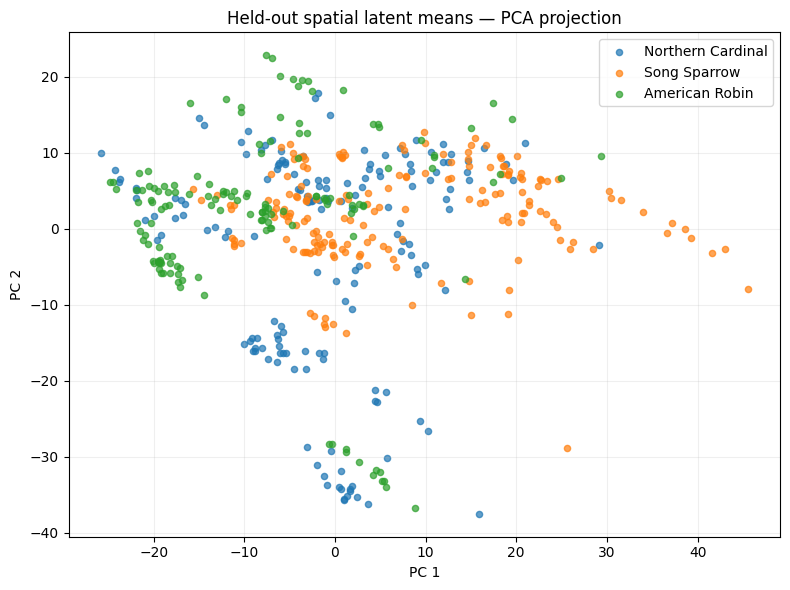

Saved: C:\Users\sheng\Documents\1508_project\bird_song_gen\outputs\conditional_vae_v2\latent_pca.png


In [19]:
@torch.no_grad()
def collect_latents(
    model: ConditionalVAE,
    loader: DataLoader,
    max_samples: int = 1000,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    latent_batches = []
    label_batches = []
    collected = 0
    for x, labels, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mu, _ = model.encode(x, labels)
        latent_batches.append(mu.flatten(1).cpu().numpy())
        label_batches.append(labels.cpu().numpy())
        collected += len(x)
        if collected >= max_samples:
            break
    return (
        np.concatenate(latent_batches, axis=0)[:max_samples],
        np.concatenate(label_batches, axis=0)[:max_samples],
    )


def pca_2d(x: np.ndarray) -> np.ndarray:
    centered = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    return centered @ vt[:2].T


if best_path.exists():
    latent_vectors, latent_labels = collect_latents(model, test_loader)
    projected = pca_2d(latent_vectors)
    fig, axis = plt.subplots(figsize=(8, 6))
    for label_id, species in id_to_label.items():
        mask = latent_labels == label_id
        axis.scatter(projected[mask, 0], projected[mask, 1], s=20, alpha=0.7, label=species)
    axis.set_title("Held-out spatial latent means — PCA projection")
    axis.set_xlabel("PC 1")
    axis.set_ylabel("PC 2")
    axis.grid(alpha=0.2)
    axis.legend()
    fig.tight_layout()
    figure_path = OUTPUT_DIR / "latent_pca.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", figure_path)
else:
    print("Train the model first.")


## 18. Save run metadata and final verification

The summary records the model scale, core hyperparameters, timing, peak memory,
best validation loss, and held-out test reconstruction metrics. This information
can be reused in the report and in the VAE-vs-diffusion comparison.


In [20]:
completed_epochs = len(history["epoch"])
best_epoch = None
if history["val_loss"]:
    best_index = int(np.argmin(history["val_loss"]))
    best_epoch = int(history["epoch"][best_index])

generated_detail_records = (
    generated_detail_comparison.to_dict(orient="records")
    if not generated_detail_comparison.empty
    else []
)
run_summary = {
    "model": "spatial_detail_class_conditional_vae_v2",
    "trained_from_scratch": True,
    "target_species": list(cfg.TARGET_SPECIES),
    "label_to_id": label_to_id,
    "input_shape": [cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE],
    "latent_shape": [cfg.LATENT_CHANNELS, cfg.LATENT_SIZE, cfg.LATENT_SIZE],
    "latent_dim": model.latent_dim,
    "class_embed_dim": cfg.CLASS_EMBED_DIM,
    "base_channels": cfg.BASE_CHANNELS,
    "total_parameters": parameter_counts["total"],
    "trainable_parameters": parameter_counts["trainable"],
    "batch_size": cfg.BATCH_SIZE,
    "learning_rate": cfg.LEARNING_RATE,
    "beta_kl": cfg.BETA_KL,
    "kl_warmup_epochs": cfg.KL_WARMUP_EPOCHS,
    "loss_weights": {
        "event": cfg.EVENT_WEIGHT,
        "multiscale": cfg.MULTISCALE_WEIGHT,
        "time_gradient": cfg.TIME_GRAD_WEIGHT,
        "frequency_gradient": cfg.FREQ_GRAD_WEIGHT,
    },
    "completed_epochs": completed_epochs,
    "best_epoch": best_epoch,
    "best_validation_loss": (
        float(min(history["val_loss"])) if history["val_loss"] else None
    ),
    "best_validation_mse": (
        float(history["val_mse"][best_index]) if best_epoch is not None else None
    ),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "generated_detail_metrics": generated_detail_records,
    "sampling_prior": {
        "type": "per_species_moment_matched_aggregated_posterior",
        "fitted_split": "train",
        "temperature": cfg.PRIOR_TEMPERATURE,
    },
    "audio_demo_paths": [str(path.resolve()) for path in audio_demo_paths],
    "training_section_seconds": float(
        total_training_seconds
        if total_training_seconds > 0
        else sum(history["epoch_seconds"])
    ),
    "mean_epoch_seconds": (
        float(np.mean(history["epoch_seconds"])) if history["epoch_seconds"] else None
    ),
    "peak_allocated_cuda_gb": peak_memory_gb,
    "device": str(DEVICE),
    "smoke_test": cfg.SMOKE_TEST,
    "best_checkpoint": str(best_path.resolve()) if best_path.exists() else None,
}

summary_path = OUTPUT_DIR / "run_summary.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(run_summary, handle, indent=2, ensure_ascii=False)

print(json.dumps(run_summary, indent=2, ensure_ascii=False))
print("Saved run summary:", summary_path)

if best_path.exists():
    assert best_path.stat().st_size > 0
    generated_manifest_path = OUTPUT_DIR / "generated_manifest.csv"
    assert generated_manifest_path.exists(), "Generated manifest is missing."
    generated_df = pd.read_csv(generated_manifest_path)
    expected_generated = len(label_to_id) * cfg.SAMPLES_PER_SPECIES
    assert len(generated_df) == expected_generated
    assert generated_df["spec_path"].map(lambda p: Path(p).exists()).all()
    print("Final artifact checks passed.")


{
  "model": "spatial_detail_class_conditional_vae_v2",
  "trained_from_scratch": true,
  "target_species": [
    "Northern Cardinal",
    "Song Sparrow",
    "American Robin"
  ],
  "label_to_id": {
    "Northern Cardinal": 0,
    "Song Sparrow": 1,
    "American Robin": 2
  },
  "input_shape": [
    1,
    128,
    128
  ],
  "latent_shape": [
    16,
    8,
    8
  ],
  "latent_dim": 1024,
  "class_embed_dim": 64,
  "base_channels": 32,
  "total_parameters": 7482017,
  "trainable_parameters": 7482017,
  "batch_size": 32,
  "learning_rate": 0.0002,
  "beta_kl": 0.001,
  "kl_warmup_epochs": 15,
  "loss_weights": {
    "event": 1.5,
    "multiscale": 0.25,
    "time_gradient": 0.5,
    "frequency_gradient": 0.5
  },
  "completed_epochs": 60,
  "best_epoch": 60,
  "best_validation_loss": 0.5166229628069552,
  "best_validation_mse": 0.06366778295020607,
  "test_metrics": {
    "loss": 0.522229205976966,
    "recon": 0.5188031039354991,
    "mse": 0.06538758829144613,
    "mae": 0.1894133

## 19. Interpretation and literature record

Do not declare the revision better from its composite training loss: that loss is
intentionally different from the original model.  Compare the shared held-out
MSE, visual preservation of narrow tracks, transient/frequency gradient metrics,
generated-detail ratios, classifier recognizability, diversity, and waveform
demonstrations.  A detail ratio close to one is necessary but not sufficient;
noise can also have strong gradients.

The implementation choices were informed by these original papers:

- Vahdat & Kautz, **NVAE: A Deep Hierarchical Variational Autoencoder** (2020),
  https://arxiv.org/abs/2007.03898
- Child, **Very Deep VAEs Generalize Autoregressive Models and Can Outperform
  Them on Images** (2021), https://arxiv.org/abs/2011.10650
- Sønderby et al., **Ladder Variational Autoencoders** (2016),
  https://arxiv.org/abs/1602.02282
- Tomczak & Welling, **VAE with a VampPrior** (2018),
  https://proceedings.mlr.press/v84/tomczak18a.html
- Caillon & Esling, **RAVE: A variational autoencoder for fast and high-quality
  neural audio synthesis** (2021), https://arxiv.org/abs/2111.05011
- Yamamoto, Song & Kim, **Parallel WaveGAN** (2020),
  https://arxiv.org/abs/1910.11480
- Mathieu, Couprie & LeCun, **Deep multi-scale video prediction beyond mean
  square error** (2016), https://arxiv.org/abs/1511.05440
- Bhatia & Kinnunen, **An Initial study on Birdsong Re-synthesis Using Neural
  Vocoders** (2022), https://arxiv.org/abs/2209.10479
- Song & Ta, **Towards High-Fidelity and Controllable Bioacoustic Generation via
  Enhanced Diffusion Learning** (2025), https://arxiv.org/abs/2509.00318

The last two also motivate keeping the claims conservative: bird-like pitch and
voicing remain difficult, field noise matters, and downstream classifier or
distributional scores should complement spectrogram inspection and listening.
